##IMPORTING THE  NEEDED LIBRARIES


In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense

import matplotlib.pyplot as plt

##DOWNLOADING THE DATASET

I would be downloading the file directly from the web as I don't have a csv file saved directly in my pc

In [2]:
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"

df = pd.read_csv(
    url,
    sep="\t",
    names=["label", "message"]
)

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


##CHECKING THE DATA FRAME

In [3]:
print(df.shape)

df['label'].value_counts()

(5572, 2)


,count
label,
ham,4825
spam,747


##CONVERTING OUR LABELS TO NUMBERS

This done because to give the computer something it can can understand and in a matrics form for the sliders to be able to do it work


In [4]:
df['label'] = df['label'].map({
    'ham':0,
    'spam':1
})

df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


## SETTING UP OUR LABVEL AND SETTING UP OUIR FEATURES

In [6]:
X = df['message']
y = df['label']

##SPLITTING THE DATA
This is done to split the df into the x and y training dataset





X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


##TOKENIZATION OF TEXT
Turning our text into numbers
---



In [9]:
max_words = 10000

tokenizer = Tokenizer(num_words=max_words)

tokenizer.fit_on_texts(X_train)

##CONVERTING TEXT INTO WORKING SEQUENCE

In [10]:
X_train_seq = tokenizer.texts_to_sequences(X_train)

X_test_seq = tokenizer.texts_to_sequences(X_test)

##SEQUENCE PADDING
From our .shape, we notice that our dataset is unequal, padding lets us equalize the length of our data

In [11]:
max_length = 100

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length
)

In [12]:
X_train_pad.shape

(4457, 100)

##BUILDING MY CNN MODEL

In [13]:
model = Sequential()

# Embedding Layer
model.add(
    Embedding(
        input_dim=max_words,
        output_dim=128,
        input_length=max_length
    )
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [14]:
# Convolution Layer
model.add(
    Conv1D(
        filters=128,
        kernel_size=5,
        activation='relu'
    )
)

In [15]:

# Pooling Layer
model.add(
    GlobalMaxPooling1D()
)


In [16]:
# Fully Connected Layer
model.add(
    Dense(
        64,
        activation='relu'
    )
)


In [17]:
# Output Layer
model.add(
    Dense(
        1,
        activation='sigmoid'
    )
)

##MODEL COMPILATION

In [18]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

##SUMMARY OF THE MODEL

In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

##TRAINING THE MODEL

In [20]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 60ms/step - accuracy: 0.9060 - loss: 0.2739 - val_accuracy: 0.9798 - val_loss: 0.0771
Epoch 2/5
112/112 ━━━━━━━━━━━━━━━━━━━━ 8s 71ms/step - accuracy: 0.9924 - loss: 0.0258 - val_accuracy: 0.9865 - val_loss: 0.0616
Epoch 3/5
112/112 ━━━━━━━━━━━━━━━━━━━━ 7s 61ms/step - accuracy: 0.9992 - loss: 0.0046 - val_accuracy: 0.9888 - val_loss: 0.0635
Epoch 4/5
112/112 ━━━━━━━━━━━━━━━━━━━━ 8s 73ms/step - accuracy: 0.9997 - loss: 0.0017 - val_accuracy: 0.9888 - val_loss: 0.0677
Epoch 5/5
112/112 ━━━━━━━━━━━━━━━━━━━━ 7s 63ms/step - accuracy: 0.9997 - loss: 0.0011 - val_accuracy: 0.9877 - val_loss: 0.0834


##TESTING THE MODEL

In [21]:
loss, accuracy = model.evaluate(
    X_test_pad,
    y_test
)

print("Accuracy:", accuracy)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9901 - loss: 0.0512
Accuracy: 0.9901345372200012


##MAKING PREDICTIONS

In [22]:
y_pred_prob = model.predict(X_test_pad)

y_pred = (
    y_pred_prob > 0.5
).astype(int)

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step


##CALCULATION METICS

In [23]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

##PRECISION TESTING

In [27]:
precision = precision_score(
    y_test,
    y_pred
)

##RECALL TESTING

In [30]:
recall = recall_score(
    y_test,
    y_pred
)

##FI SCORE

In [31]:
f1 = f1_score(
    y_test,
    y_pred
)

In [32]:
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9901345291479821
Precision: 0.9791666666666666
Recall   : 0.9463087248322147
F1 Score : 0.962457337883959


##PERFORMANCE VISUALIZATION



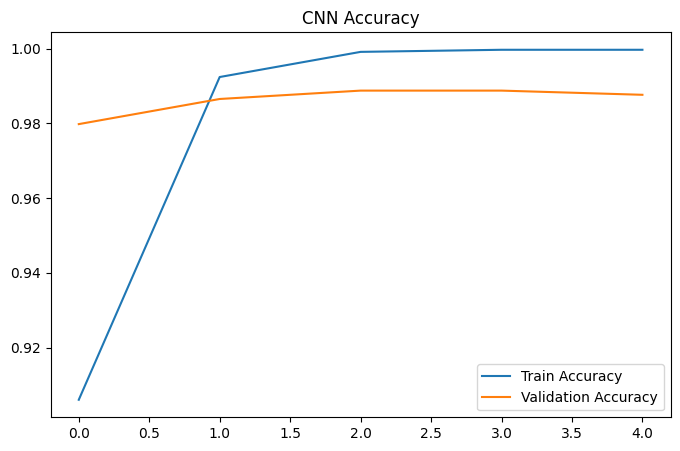

In [33]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.legend()
plt.title("CNN Accuracy")
plt.show()



```
`# This is formatted as code`
```

